# More models for R(t)

In [2]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

## Season-enveloped logistic R(t)

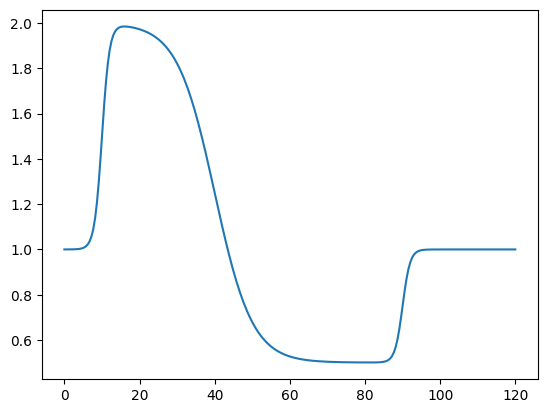

In [17]:
# =
def logistic(t, t0, w):
    return 1 / (1 + np.exp(-(t - t0) / w))



def enveloped_logistic_rt(
        t,
        t_start, dt_mid, dt_end,
        r_high, r_low,
        w_env, w_mid, **kwargs
):
    t_mid = t_start + dt_mid
    t_end = t_start + dt_end
    return (
        1 + (
            (logistic(t, t_start, w_env) - logistic(t, t_end, w_env))  # Envelope
            * (r_high - 1 - (r_high - r_low) * logistic(t, t_mid, w_mid))
        )
    )

# ====

class _Params:
    t_start   = 10
    dt_mid    = 30
    dt_end    = 80
    r_high    = 2
    r_low     = 0.5
    w_env     = 1
    w_mid     = 5

t_array = np.linspace(0, 120, 250)
rt_array = enveloped_logistic_rt(
    t_array, **_Params.__dict__
)

fig, ax = plt.subplots()

ax.plot(t_array, rt_array)
